# XGBoost Ablation Study for Noise Classification

This notebook compares baseline and feature-variant XGBoost classifiers for `noise_day`. It is designed to justify feature removal and feature engineering with a reproducible ablation workflow.

Notes:
- The baseline keeps the original candidate predictors and tests drops one by one.
- `transport` and `signals` are evaluated separately because they are correlated.
- Engineered features are tested one at a time before trying a combined variant.
- If a local-closeness column is added later, the notebook will detect it and test it as an extra candidate rather than forcing it into the baseline.

In [12]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [13]:
DATA_PATH = Path('data/bcn_noise_class_ml_dataset.csv')

data = pd.read_csv(DATA_PATH)
data_clean = data.dropna(how='any').reset_index(drop=True)

print(f'Rows: {len(data_clean):,}')
print(f'Columns: {len(data_clean.columns)}')
print(sorted(data_clean.columns.tolist()))

Rows: 11,711
Columns: 21
['betw_centrality', 'clos_centrality', 'closeness400', 'dist_to_living_street', 'dist_to_primary', 'dist_to_residential', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_trunk', 'green_100', 'height', 'noise_day', 'noise_evening', 'noise_night', 'pois', 'road_category', 'road_id', 'signals', 'straightness', 'transport', 'width']


## Baseline Setup

The baseline includes all current explanatory variables except identifiers and targets. Feature drops are then tested relative to that baseline.

In [14]:
TARGET = 'noise_day'
TARGETS_TO_EXCLUDE = ['noise_day', 'noise_evening', 'noise_night']
ID_COLUMNS = ['road_id', 'segment_id']

all_features = [
    column for column in data_clean.columns
    if column not in TARGETS_TO_EXCLUDE + ID_COLUMNS
]

print('Baseline features:')
print(all_features)

Baseline features:
['road_category', 'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'width', 'height', 'betw_centrality', 'clos_centrality', 'green_100', 'straightness', 'closeness400']


## Correlation Check

This is not the decision step by itself, but it helps explain why some variants are worth testing, especially `signals` versus `transport`.

In [15]:
corr = data_clean[all_features + [TARGET]].corr(numeric_only=True)
target_corr = corr[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
display(target_corr.to_frame('corr_with_noise_day'))

pairwise = corr.loc[all_features, all_features].copy()
strong_pairs = []
for left in pairwise.columns:
    for right in pairwise.columns:
        if left >= right:
            continue
        value = pairwise.loc[left, right]
        if abs(value) >= 0.7:
            strong_pairs.append((left, right, value))

strong_pairs_df = pd.DataFrame(strong_pairs, columns=['feature_a', 'feature_b', 'correlation'])
strong_pairs_df = strong_pairs_df.sort_values('correlation', key=lambda s: s.abs(), ascending=False)
display(strong_pairs_df)

,corr_with_noise_day
straightness,0.407089
road_category,-0.400116
clos_centrality,0.362616
dist_to_primary,-0.307906
betw_centrality,0.292663
signals,0.241040
dist_to_tertiary,-0.230860
dist_to_secondary,-0.220129
closeness400,0.179406
green_100,-0.178689


,feature_a,feature_b,correlation
0,signals,transport,0.744887
1,clos_centrality,dist_to_primary,-0.702190


## Define Variants

The study below tests five types of variants:
- baseline and drop-one-feature variants
- grouped drop variants based on the current hypothesis
- road-category versus distance-to-category comparison variants
- engineered-feature variants added on top of the baseline
- replacement variants where engineered features substitute for their raw input columns

In [ ]:
from itertools import combinations

def build_feature_frame(df: pd.DataFrame) -> pd.DataFrame:
    X = df[all_features].copy()
    X['width_x_betw'] = X['width'] * X['betw_centrality']
    X['clos_x_straightness'] = X['closeness400'] * X['straightness']
    X['min_arterial_dist'] = X[['dist_to_trunk', 'dist_to_primary', 'dist_to_secondary']].min(axis=1)
    X['min_local_road_dist'] = X[['dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street']].min(axis=1)
    return X

feature_frame = build_feature_frame(data_clean)
y = data_clean[TARGET].copy()

baseline_features = all_features.copy()
engineered_features = [
    'width_x_betw',
    'clos_x_straightness',
    'min_arterial_dist',
    'min_local_road_dist',
]

distance_to_category_features = [
    'dist_to_trunk',
    'dist_to_primary',
    'dist_to_secondary',
    'dist_to_tertiary',
    'dist_to_residential',
    'dist_to_living_street',
]
arterial_distance_features = ['dist_to_trunk', 'dist_to_primary', 'dist_to_secondary']
local_distance_features = ['dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street']
width_betw_features = ['width', 'betw_centrality']
closeness_straightness_features = ['closeness400', 'straightness']
priority_drop_candidates = [
    feature for feature in ['transport', 'pois', 'green_100', 'signals']
    if feature in baseline_features
]

drop_one_variants = {
    f'drop_{feature}': [candidate for candidate in baseline_features if candidate != feature]
    for feature in baseline_features
}

priority_combo_variants = {}
for size in range(2, len(priority_drop_candidates) + 1):
    for combo in combinations(priority_drop_candidates, size):
        variant_name = 'drop_combo_' + '_'.join(combo)
        priority_combo_variants[variant_name] = [
            feature for feature in baseline_features
            if feature not in combo
        ]

category_comparison_variants = {
    'road_category_only': ['road_category'],
    'distance_to_category_only': distance_to_category_features,
    'drop_road_category': [feature for feature in baseline_features if feature != 'road_category'],
    'drop_distance_to_category_features': [
        feature for feature in baseline_features
        if feature not in distance_to_category_features
    ],
}

variants = {
    'baseline_all_features': baseline_features,
    **drop_one_variants,
    **priority_combo_variants,
    **category_comparison_variants,
    'add_width_x_betw': baseline_features + ['width_x_betw'],
    'add_clos_x_straightness': baseline_features + ['clos_x_straightness'],
    'add_min_arterial_dist': baseline_features + ['min_arterial_dist'],
    'add_min_local_road_dist': baseline_features + ['min_local_road_dist'],
    'add_best_three_engineered': baseline_features + ['width_x_betw', 'clos_x_straightness', 'min_arterial_dist'],
    'add_all_engineered': baseline_features + engineered_features,
    'replace_width_and_betw_with_interaction': [
        feature for feature in baseline_features
        if feature not in width_betw_features
    ] + ['width_x_betw'],
    'replace_closeness_and_straightness_with_interaction': [
        feature for feature in baseline_features
        if feature not in closeness_straightness_features
    ] + ['clos_x_straightness'],
    'replace_arterial_distances_with_min': [
        feature for feature in baseline_features
        if feature not in arterial_distance_features
    ] + ['min_arterial_dist'],
    'replace_local_distances_with_min': [
        feature for feature in baseline_features
        if feature not in local_distance_features
    ] + ['min_local_road_dist'],
}

variant_sizes = pd.Series({name: len(cols) for name, cols in variants.items()}).sort_values()
print(f'Total variants: {len(variants)}')
variant_sizes

Total variants: 43


road_category_only                                      1
distance_to_category_only                               6
drop_distance_to_category_features                     11
drop_combo_transport_pois_green_100_signals            13
drop_combo_pois_green_100_signals                      14
drop_combo_transport_green_100_signals                 14
drop_combo_transport_pois_signals                      14
drop_combo_transport_pois_green_100                    14
drop_combo_pois_signals                                15
drop_combo_green_100_signals                           15
drop_combo_transport_green_100                         15
drop_combo_transport_pois                              15
drop_combo_pois_green_100                              15
drop_combo_transport_signals                           15
replace_arterial_distances_with_min                    15
replace_local_distances_with_min                       15
drop_signals                                           16
drop_green_100

## Evaluation Function

Each variant uses the same model family and the same 5-fold stratified split. The only thing that changes is the feature set. That is the core idea of the ablation study.

In [17]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_model() -> xgb.XGBClassifier:
    return xgb.XGBClassifier(
    )

def evaluate_variant(X: pd.DataFrame, y: pd.Series, selected_features: list[str]) -> dict:
    accuracy_scores = []
    macro_f1_scores = []

    for train_idx, test_idx in skf.split(X[selected_features], y):
        X_train = X.iloc[train_idx][selected_features]
        X_test = X.iloc[test_idx][selected_features]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model = make_model()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy_scores.append(accuracy_score(y_test, y_pred))
        macro_f1_scores.append(f1_score(y_test, y_pred, average='macro'))

    return {
        'n_features': len(selected_features),
        'accuracy_mean': np.mean(accuracy_scores),
        'accuracy_std': np.std(accuracy_scores),
        'macro_f1_mean': np.mean(macro_f1_scores),
        'macro_f1_std': np.std(macro_f1_scores),
    }

In [18]:
results = []
for variant_name, selected_features in variants.items():
    metrics = evaluate_variant(feature_frame, y, selected_features)
    results.append({'variant': variant_name, **metrics})

results_df = pd.DataFrame(results).sort_values(
    by=['macro_f1_mean', 'accuracy_mean'],
    ascending=False
).reset_index(drop=True)

baseline_accuracy = results_df.loc[results_df['variant'] == 'baseline_all_features', 'accuracy_mean'].iloc[0]
baseline_macro_f1 = results_df.loc[results_df['variant'] == 'baseline_all_features', 'macro_f1_mean'].iloc[0]

results_df['delta_accuracy_vs_baseline'] = results_df['accuracy_mean'] - baseline_accuracy
results_df['delta_macro_f1_vs_baseline'] = results_df['macro_f1_mean'] - baseline_macro_f1

results_df

,variant,n_features,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,delta_accuracy_vs_baseline,delta_macro_f1_vs_baseline
0,add_min_arterial_dist,18,0.720093,0.009237,0.675580,0.015458,0.002134,0.003133
1,drop_height,16,0.718897,0.008496,0.675089,0.014138,0.000939,0.002642
2,drop_width,16,0.719068,0.009659,0.674249,0.020144,0.001110,0.001802
3,add_best_three_engineered,20,0.718470,0.005806,0.674194,0.016542,0.000511,0.001747
4,drop_road_category,16,0.718470,0.005519,0.673963,0.011825,0.000512,0.001516
5,add_best_three_engineered_without_pois_signals,18,0.719152,0.006699,0.673756,0.010457,0.001193,0.001309
6,drop_dist_to_living_street,16,0.719240,0.010182,0.672773,0.016132,0.001281,0.000325
7,replace_width_and_betw_with_interaction,16,0.713262,0.006738,0.672762,0.015763,-0.004697,0.000314
8,add_min_local_road_dist,18,0.718641,0.007656,0.672719,0.016743,0.000683,0.000272
9,add_clos_x_straightness,18,0.721459,0.008916,0.672583,0.014477,0.003501,0.000136


## Drop-One and Group-Drop Summaries

These filtered tables make it easier to answer two questions directly: which single features can be dropped, and which combinations of `transport`, `pois`, `green_100`, and `signals` can be dropped together.

In [19]:
drop_one_results = results_df[results_df['variant'].str.startswith('drop_') & ~results_df['variant'].str.startswith('drop_combo_')].copy()
drop_one_results = drop_one_results.sort_values('delta_macro_f1_vs_baseline', ascending=False)
display(drop_one_results)

priority_combo_results = results_df[results_df['variant'].str.startswith('drop_combo_')].copy()
priority_combo_results = priority_combo_results.sort_values('delta_macro_f1_vs_baseline', ascending=False)
display(priority_combo_results)

,variant,n_features,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,delta_accuracy_vs_baseline,delta_macro_f1_vs_baseline
1,drop_height,16,0.718897,0.008496,0.675089,0.014138,0.000939,0.002642
2,drop_width,16,0.719068,0.009659,0.674249,0.020144,0.001110,0.001802
4,drop_road_category,16,0.718470,0.005519,0.673963,0.011825,0.000512,0.001516
6,drop_dist_to_living_street,16,0.719240,0.010182,0.672773,0.016132,0.001281,0.000325
13,drop_signals,16,0.719496,0.008028,0.671096,0.015378,0.001537,-0.001352
15,drop_clos_centrality,16,0.714457,0.007611,0.670226,0.016358,-0.003502,-0.002221
17,drop_transport,16,0.717360,0.004569,0.669688,0.013415,-0.000598,-0.002759
18,drop_betw_centrality,16,0.714969,0.004978,0.669233,0.015172,-0.002989,-0.003214
20,drop_green_100,16,0.717617,0.009413,0.669024,0.015497,-0.000342,-0.003423
21,drop_straightness,16,0.714030,0.009171,0.668926,0.015120,-0.003929,-0.003521


,variant,n_features,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,delta_accuracy_vs_baseline,delta_macro_f1_vs_baseline
11,drop_combo_pois_green_100,15,0.716848,0.006631,0.671966,0.013129,-0.001110,-0.000481
16,drop_combo_pois_signals,15,0.717616,0.004791,0.669814,0.014858,-0.000343,-0.002633
19,drop_combo_transport_green_100,15,0.714543,0.007230,0.669182,0.015383,-0.003416,-0.003265
24,drop_combo_transport_pois,15,0.717446,0.003194,0.668460,0.008735,-0.000513,-0.003987
27,drop_combo_transport_pois_green_100,14,0.714969,0.009470,0.668021,0.012947,-0.002989,-0.004426
28,drop_combo_pois_green_100_signals,14,0.716250,0.002035,0.666483,0.013441,-0.001709,-0.005965
29,drop_combo_transport_pois_signals,14,0.715141,0.010549,0.666242,0.014451,-0.002818,-0.006205
30,drop_combo_green_100_signals,15,0.716506,0.006756,0.665893,0.016126,-0.001452,-0.006554
31,drop_combo_transport_pois_green_100_signals,13,0.710187,0.002872,0.664568,0.011775,-0.007772,-0.007879
32,drop_combo_transport_signals,15,0.717616,0.005848,0.664371,0.014787,-0.000343,-0.008076


## Road Category vs Distance-to-Category

This comparison isolates whether `road_category` is carrying similar information to the distance-to-category variables, or whether both representations are useful together.

In [20]:
road_category_variants = [
    'baseline_all_features',
    'road_category_only',
    'distance_to_category_only',
    'drop_road_category',
    'drop_distance_to_category_features',
]

road_category_results = results_df[results_df['variant'].isin(road_category_variants)].copy()
road_category_results = road_category_results.sort_values('macro_f1_mean', ascending=False)
display(road_category_results)

,variant,n_features,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,delta_accuracy_vs_baseline,delta_macro_f1_vs_baseline
4,drop_road_category,16,0.718470,0.005519,0.673963,0.011825,0.000512,0.001516
10,baseline_all_features,17,0.717959,0.009964,0.672447,0.015314,0.000000,0.000000
40,distance_to_category_only,6,0.693792,0.004806,0.652338,0.009901,-0.024166,-0.020109
41,drop_distance_to_category_features,11,0.685340,0.008074,0.627904,0.022476,-0.032619,-0.044544
42,road_category_only,1,0.536760,0.009879,0.203018,0.008276,-0.181198,-0.469429


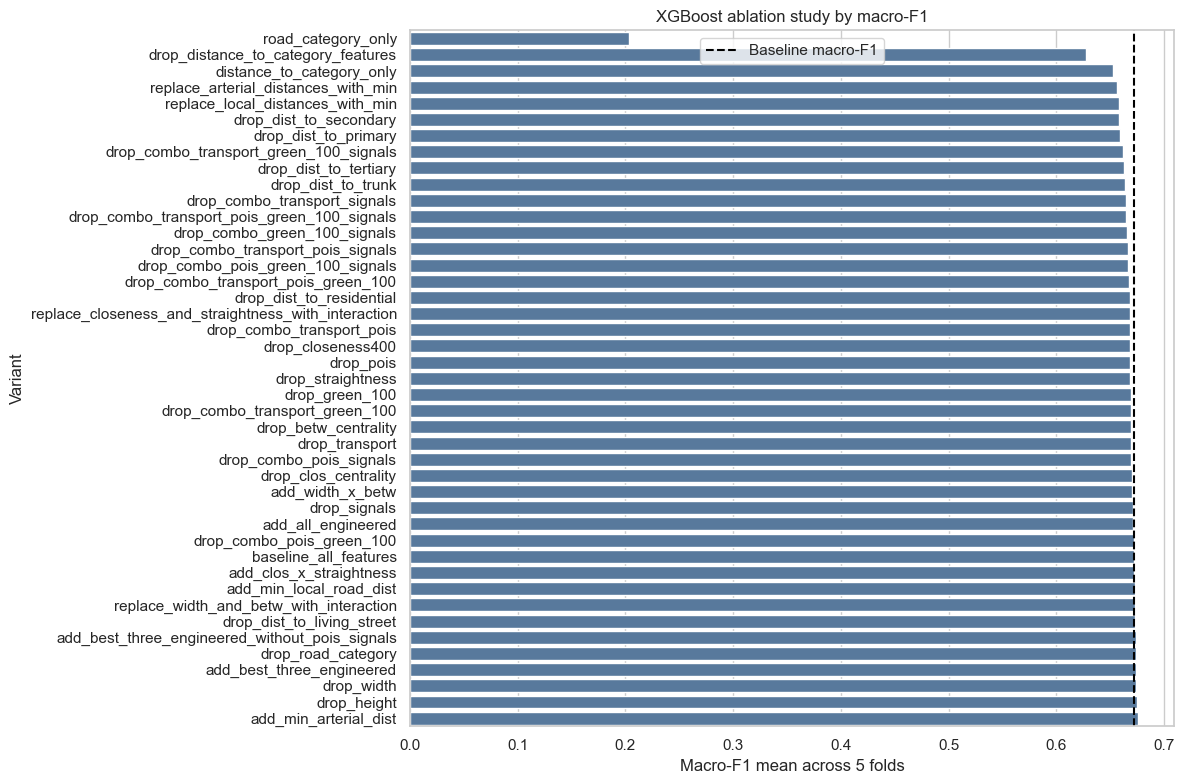

In [21]:
plot_df = results_df.sort_values('macro_f1_mean', ascending=True)
plt.figure(figsize=(12, 8))
sns.barplot(data=plot_df, y='variant', x='macro_f1_mean', color='#4C78A8')
plt.axvline(baseline_macro_f1, color='black', linestyle='--', label='Baseline macro-F1')
plt.title('XGBoost ablation study by macro-F1')
plt.xlabel('Macro-F1 mean across 5 folds')
plt.ylabel('Variant')
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation Template

Use the table above to justify decisions in the report. A simple interpretation structure is:

1. Start from `baseline_all_features`.
2. Check `drop_one_results` to see which individual features improve or do not materially hurt performance when removed.
3. Check `priority_combo_results` to see whether `transport`, `pois`, `green_100`, and `signals` can be dropped together.
4. Check `road_category_results` to compare `road_category` against the distance-to-category variables.
5. If an engineered-feature variant improves the baseline, keep that engineered feature as a candidate for the final model.
6. Prefer decisions supported by both `macro_f1_mean` and `accuracy_mean`, not just one metric.

In [22]:
best_variant = results_df.iloc[0]
print('Best variant:')
display(best_variant.to_frame(name='value'))

print('Baseline vs top variants:')
display(results_df.head(5))

Best variant:


,value
variant,add_min_arterial_dist
n_features,18
accuracy_mean,0.720093
accuracy_std,0.009237
macro_f1_mean,0.67558
macro_f1_std,0.015458
delta_accuracy_vs_baseline,0.002134
delta_macro_f1_vs_baseline,0.003133


Baseline vs top variants:


,variant,n_features,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,delta_accuracy_vs_baseline,delta_macro_f1_vs_baseline
0,add_min_arterial_dist,18,0.720093,0.009237,0.675580,0.015458,0.002134,0.003133
1,drop_height,16,0.718897,0.008496,0.675089,0.014138,0.000939,0.002642
2,drop_width,16,0.719068,0.009659,0.674249,0.020144,0.001110,0.001802
3,add_best_three_engineered,20,0.718470,0.005806,0.674194,0.016542,0.000511,0.001747
4,drop_road_category,16,0.718470,0.005519,0.673963,0.011825,0.000512,0.001516
